# Phase 1: Exploratory Data Analysis

**Goal:** Understand the dataset structure, the severity of class imbalance, and the relationships between features and the fraud label.
**Dataset:** Kaggle Credit Card Fraud Detection — 284,807 transactions, 492 fraudulent (0.17%)

**Data source:** AWS S3 bucket (configured in `config/aws_config.py`)

In [17]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load & Basic Inspection

In [18]:
# Load data from S3
from config.aws_config import read_csv_from_s3, S3_BUCKET, S3_DATA_PREFIX

s3_key = f"{S3_DATA_PREFIX}/creditcard.csv"
df = read_csv_from_s3(s3_key)

print(f'Loaded from S3: s3://{S3_BUCKET}/{s3_key}')
print(f'Shape: {df.shape}')
df.head()

Loaded from S3: s3://raw-creditcard-fraud-data-v1-759302162548-eu-central-1-an/data/raw/creditcard.csv
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# Check for nulls
print('Null counts:')
print(df.isnull().sum().sum(), 'total nulls')

Null counts:
0 total nulls


## 2. Class Imbalance

This is the most important property of the dataset to understand before modeling.

Legitimate transactions: 284,315
Fraudulent transactions:  492
Fraud rate: 0.1727%


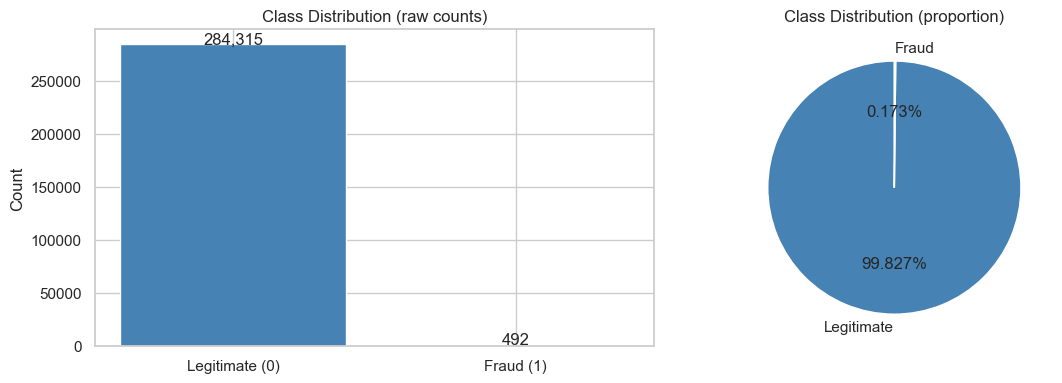

In [12]:
class_counts = df['Class'].value_counts()
fraud_rate = class_counts[1] / len(df) * 100

print(f'Legitimate transactions: {class_counts[0]:,}')
print(f'Fraudulent transactions:  {class_counts[1]:,}')
print(f'Fraud rate: {fraud_rate:.4f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (raw counts)')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center')

axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'crimson'], autopct='%1.3f%%', startangle=90)
axes[1].set_title('Class Distribution (proportion)')

plt.tight_layout()
plt.savefig('../data/eda_class_distribution.png', dpi=120)
plt.show()

**Key insight:** A naive model that always predicts "legitimate" would achieve 99.83% accuracy — this is why **accuracy is a useless metric here**. We must focus on Precision, Recall, and especially **AUC-PR** (Area Under the Precision-Recall Curve).

## 3. Feature Distributions: Amount & Time

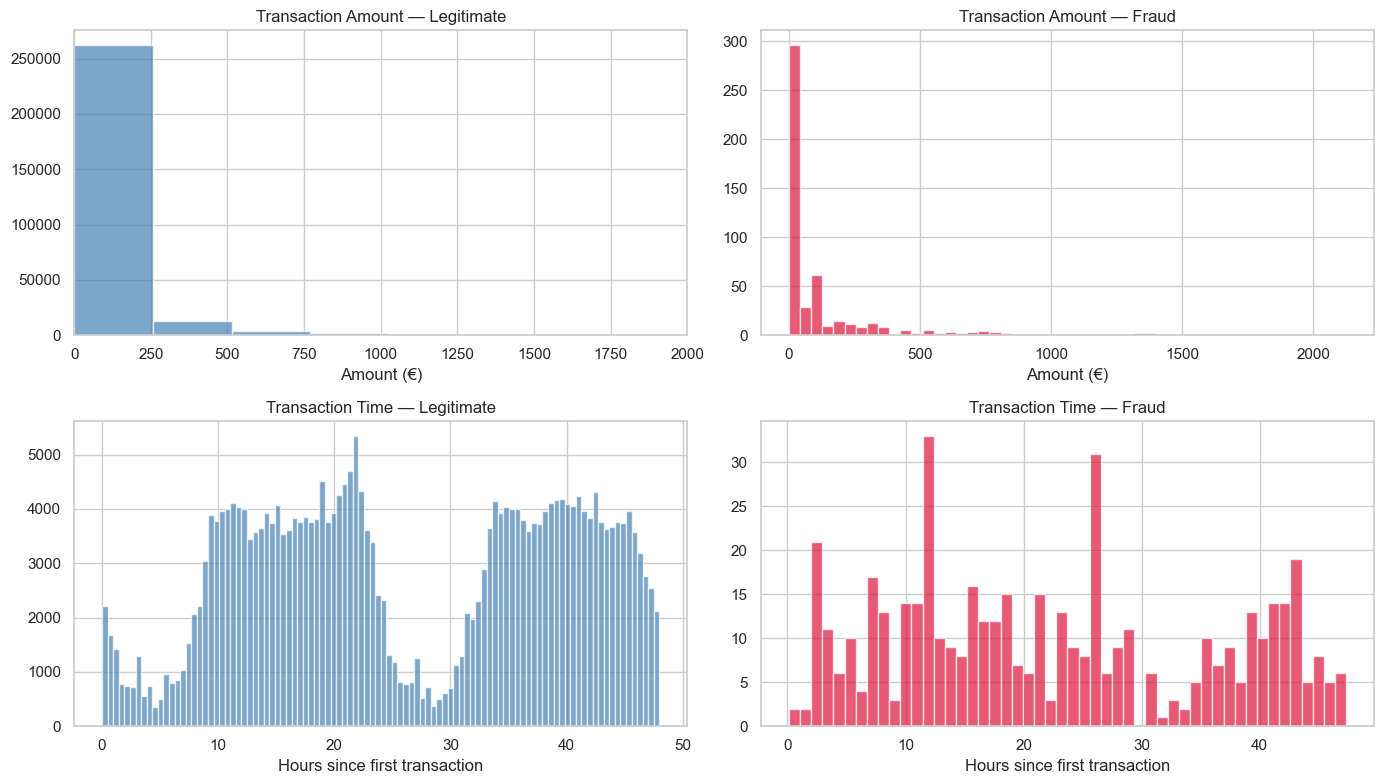

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Amount distribution
axes[0, 0].hist(df[df['Class'] == 0]['Amount'], bins=100, color='steelblue', alpha=0.7, label='Legitimate')
axes[0, 0].set_title('Transaction Amount — Legitimate')
axes[0, 0].set_xlabel('Amount (€)')
axes[0, 0].set_xlim(0, 2000)

axes[0, 1].hist(df[df['Class'] == 1]['Amount'], bins=50, color='crimson', alpha=0.7, label='Fraud')
axes[0, 1].set_title('Transaction Amount — Fraud')
axes[0, 1].set_xlabel('Amount (€)')

# Time distribution
axes[1, 0].hist(df[df['Class'] == 0]['Time'] / 3600, bins=100, color='steelblue', alpha=0.7)
axes[1, 0].set_title('Transaction Time — Legitimate')
axes[1, 0].set_xlabel('Hours since first transaction')

axes[1, 1].hist(df[df['Class'] == 1]['Time'] / 3600, bins=50, color='crimson', alpha=0.7)
axes[1, 1].set_title('Transaction Time — Fraud')
axes[1, 1].set_xlabel('Hours since first transaction')

plt.tight_layout()
plt.savefig('../data/eda_amount_time.png', dpi=120)
plt.show()

In [7]:
print('Amount statistics by class:')
print(df.groupby('Class')['Amount'].describe())

Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


## 4. V1–V28 Feature Distributions by Class

The V features are PCA-transformed for privacy, but we can still see which ones separate fraud from legitimate transactions.

In [8]:
v_features = [f'V{i}' for i in range(1, 29)]

# Compare means: fraud vs legitimate for each V feature
means = df.groupby('Class')[v_features].mean().T
means.columns = ['Legitimate', 'Fraud']
means['diff'] = (means['Fraud'] - means['Legitimate']).abs()
means_sorted = means.sort_values('diff', ascending=False)

print('Top 10 features by mean difference (fraud vs legitimate):')
print(means_sorted.head(10))

Top 10 features by mean difference (fraud vs legitimate):
     Legitimate     Fraud      diff
V3     0.012171 -7.033281  7.045452
V14    0.012064 -6.971723  6.983787
V17    0.011535 -6.665836  6.677371
V12    0.010832 -6.259393  6.270225
V10    0.009824 -5.676883  5.686707
V7     0.009637 -5.568731  5.578368
V1     0.008258 -4.771948  4.780206
V4    -0.007860  4.542029  4.549889
V16    0.007164 -4.139946  4.147110
V11   -0.006576  3.800173  3.806749


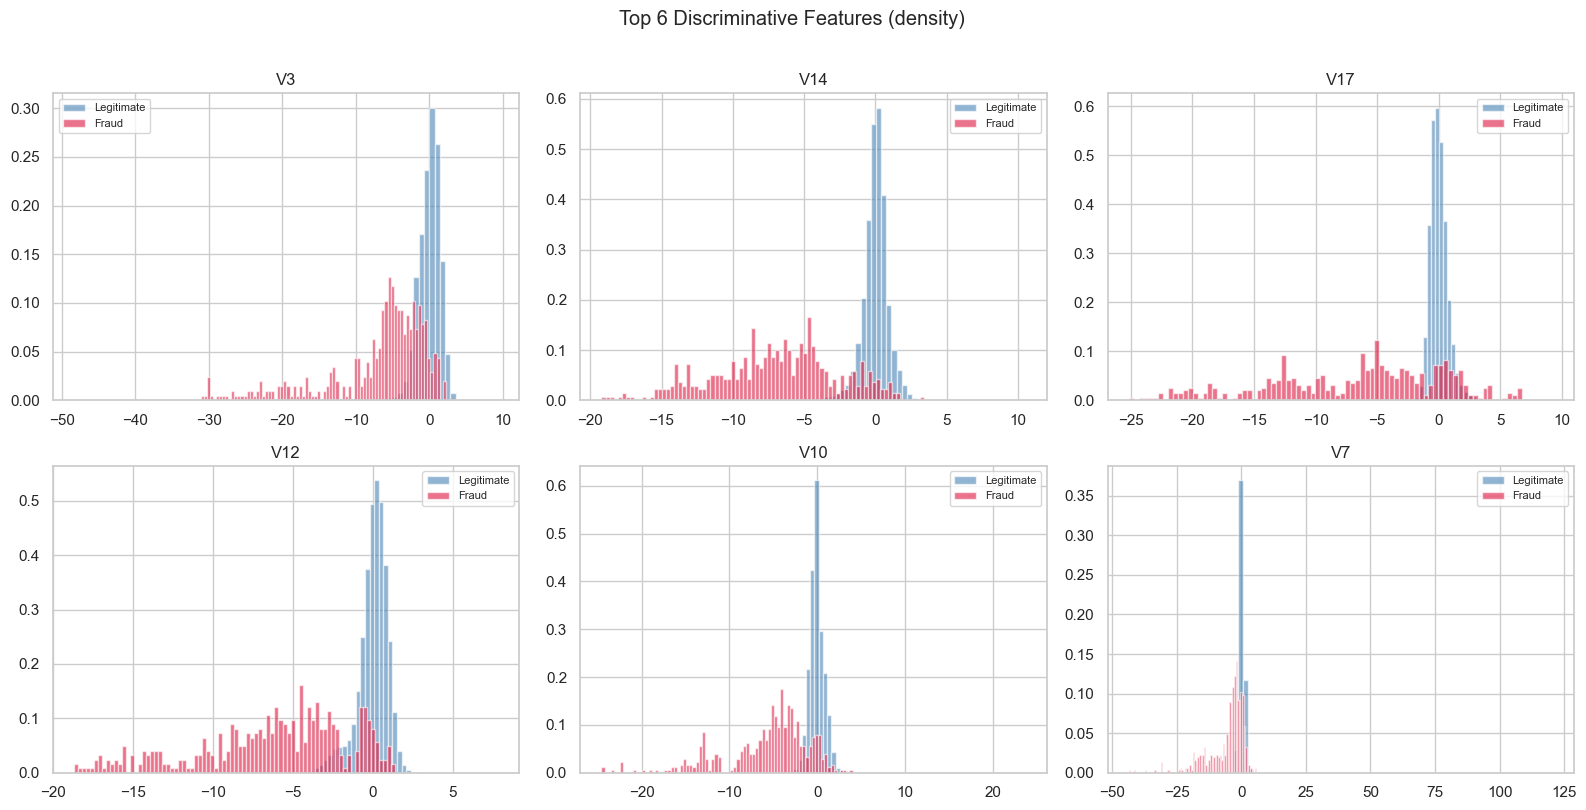

In [14]:
# Visualise top 6 most discriminative features
top_features = means_sorted.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, top_features):
    ax.hist(df[df['Class'] == 0][feat], bins=80, color='steelblue', alpha=0.6, density=True, label='Legitimate')
    ax.hist(df[df['Class'] == 1][feat], bins=80, color='crimson', alpha=0.6, density=True, label='Fraud')
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Top 6 Discriminative Features (density)', y=1.01)
plt.tight_layout()
plt.savefig('../data/eda_top_features.png', dpi=120)
plt.show()

## 5. Correlation Heatmap

In [10]:
# Correlation with Class label
corr_with_class = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
print('Features most correlated with Class (fraud):')
print(corr_with_class.head(15))

Features most correlated with Class (fraud):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V2     0.091289
V6    -0.043643
Name: Class, dtype: float64


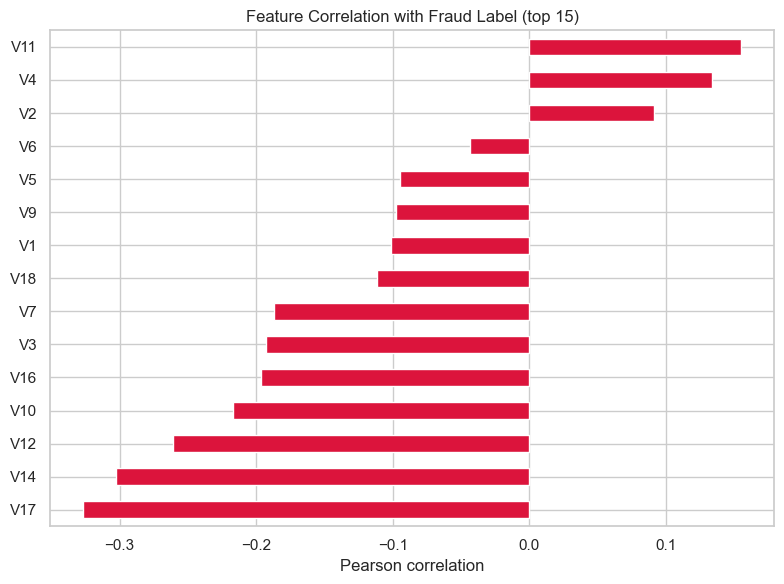

In [15]:
plt.figure(figsize=(8, 6))
corr_with_class.head(15).sort_values().plot(kind='barh', color='crimson')
plt.title('Feature Correlation with Fraud Label (top 15)')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.savefig('../data/eda_correlations.png', dpi=120)
plt.show()

## 6. Summary of EDA Findings

| Finding | Implication |
|---|---|
| Fraud rate = 0.17% | Accuracy is meaningless; use Precision, Recall, AUC-PR |
| V1–V28 already normalized | Only Amount and Time need scaling |
| V4, V11, V14, V17 most discriminative | Tree models will leverage these heavily |
| Fraud amounts not dramatically higher | Can't use a simple threshold on amount |
| No null values | No imputation needed |

**Next step → `02_baseline.ipynb`**: scale features, create stratified splits, train a logistic regression baseline.